# Parallelization

## Definition of Parallelization

Parallelization is a technique where multiple independent tasks are executed simultaneously instead of running them one after another. When tasks do not depend on each other's outputs, they can be processed in parallel, which can improve the efficiency and reduce the overall execution time of a workflow.

In LangGraph, parallelization allows multiple independent nodes to execute at the same time. Their outputs can then be combined by a downstream node, such as an aggregator, to produce the final result.

## How Parallelization Works with LangGraph

1. **Identify Independent Tasks:** Start by breaking down the problem into smaller tasks that do not depend on each other's outputs. For example, when creating a story, you can generate characters, settings, and premises independently.

2. **Create Independent Nodes:** Each independent task becomes a separate node in the LangGraph. These nodes can perform their operations independently.

3. **Connect to a Common Starting Point:** Connect the independent nodes to a common starting point, such as START or another upstream node. LangGraph can then execute these nodes in parallel.

4. **Aggregate the Results:** Connect the independent nodes to a downstream node, such as an aggregator, where their outputs are combined and processed together.

5. **Generate the Final Output:** The aggregator uses the results from the parallel nodes to produce the final output of the workflow.

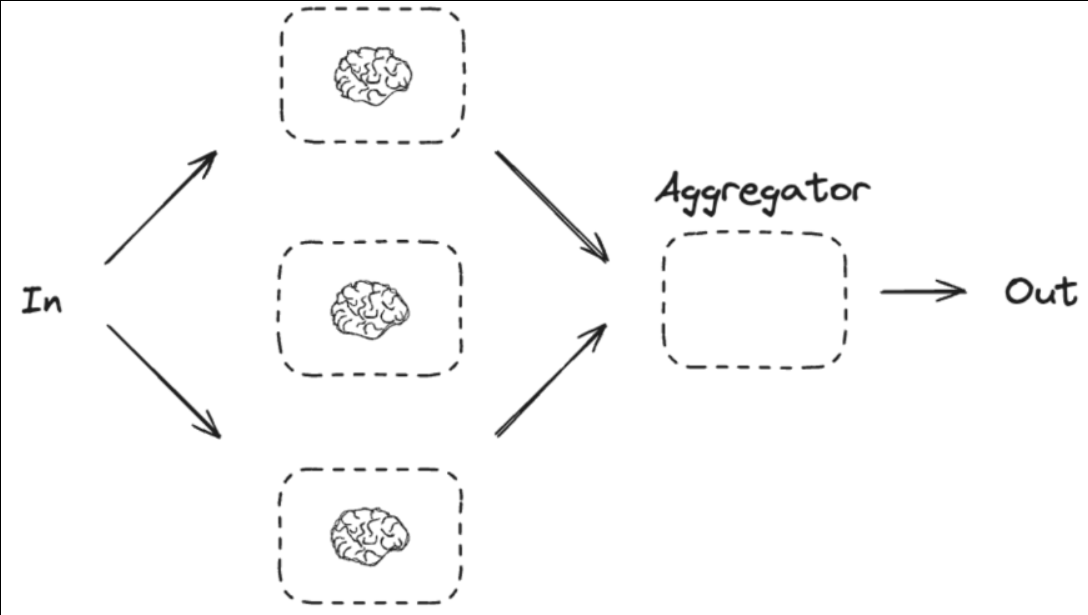

## Benefits of Parallelization with LangGraph

- **Speed:** Reduces total execution time by running tasks concurrently.

- **Scalability:** Handles larger workflows efficiently.

- **Modularity:** Keeps the graph structure clean and reusable.

## Key Takeaways of Parallelization with LangGraph

- **When to Parallelize:** Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- **Merging:** Downstream nodes can aggregate parallel results.

- **LangGraph Support:** The framework naturally supports this by waiting for all required inputs before proceeding.

## Problem Statement

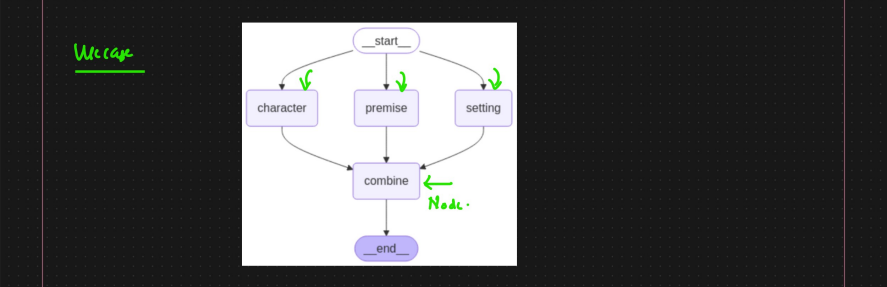

## Solution

### Setting Up the Chat Model

In [2]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="openai/gpt-oss-120b")

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond as per policy. The user just says "Hello". We should greet them. Simple.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.084921728, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.00264841, 'prompt_tokens_details': None, 'queue_time': 0.317042556, 'total_time': 0.087570138}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_854fa9be4c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fb40-bce0-7b00-b023-4301c2471572-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})

### Defining the State Schema and Graph Nodes

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Creating the Graph State
class State(TypedDict):
    topic:str
    characters:str
    settings:str
    premises:str
    story_intro:str

### Defining the Graph Nodes

In [4]:
def generate_characters(state: State):
    """Generate character descriptions"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, setting, and premise into an intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )
    return {"story_intro": msg.content}

### Building the Parallel Graph

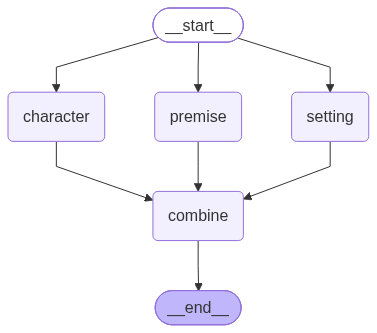

In [5]:
### Creating the StateGraph
graph = StateGraph(State)

### Adding the Graph Nodes
graph.add_node("character", generate_characters)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

### Adding the Graph Edges
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

### Compiling the Graph
compiled_graph = graph.compile()

### Visualizing the Graph
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

### Running the Parallel Graph

In [6]:
state = {"topic": "time travel"}
result = compiled_graph.invoke(state)
print(result["story_intro"])

The mouth of the Chrono‑Canyon yawned like a wound in the world, its walls a palimpsest of ages that glittered and rusted in the same breath. A perpetual twilight hung over a river of liquid mercury, its surface rippling with ghostly silhouettes—cavemen huddled by fire, Victorian engineers polishing brass gears, a lone astronaut floating in a vacuum that seemed to pulse with a violet glow. The air thrummed with a low, organ‑like hum, and every gust carried a chorus of ticks, chimes, and the distant clang of a forge long turned to ash.

Aria Selwyn stood at the canyon’s edge, notebook clenched in one hand, the other hovering over the sleek, humming frame of the Chrono‑Lattice she had built in secret after the board stripped her of funding. The pocket‑sized sketchbook—filled with doodles of clocks whose hands spiraled into constellations—was open to a page where a tiny, ink‑black hourglass hovered above a map of the Milky Way. She traced the line with a fingertip, eyes flicking between t